# 3x3 Groundwater Theta-Method Demo

This notebook demonstrates one implicit timestep (theta = 1) for a 3x3 groundwater grid with:
- no sources/sinks
- constant transmissivity
- no-flow outer boundary
- known initial heads at time n

We assemble the linear system `A h^(n+1) = hs` and solve for the next timestep.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Grid and model parameters
nrows, ncols = 3, 3
N = nrows * ncols
dx = 1.0
dt = 1.0
theta = 1.0   # fully implicit
T = 1.0       # constant interface transmissivity
C = 1.0
alpha = C * dx**2 / dt

# Initial head at time n: center mound
h_n = np.array([
    [0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0],
], dtype=float)

# Tiny source term RR (added water per timestep)
RR = np.zeros((nrows, ncols), dtype=float)
RR[0, 1] = 0.02
RR[2, 1] = 0.01

# Tiny sink term SINK (removed water per timestep), in different cells
SINK = np.zeros((nrows, ncols), dtype=float)
SINK[0, 2] = 0.015
SINK[2, 0] = 0.01

h_n_flat = h_n.ravel()
RR_flat = RR.ravel()
SINK_flat = SINK.ravel()
print('Initial head h^n:')
print(h_n)
print('\nSource RR per timestep:')
print(RR)
print('\nSink SINK per timestep:')
print(SINK)
print('alpha =', alpha)

Initial head h^n:
[[0. 0. 0.]
 [0. 1. 0.]
 [0. 0. 0.]]

Source RR per timestep:
[[0.   0.02 0.  ]
 [0.   0.   0.  ]
 [0.   0.01 0.  ]]

Sink SINK per timestep:
[[0.    0.    0.015]
 [0.    0.    0.   ]
 [0.01  0.    0.   ]]
alpha = 1.0


In [2]:
def idx(i, j, ncols):
    return i * ncols + j

# Assemble dense A and hs for clarity (for large grids, sparse is preferred)
A = np.zeros((N, N), dtype=float)
hs = np.zeros(N, dtype=float)

for i in range(nrows):
    for j in range(ncols):
        p = idx(i, j, ncols)

        neighbors = []
        if i > 0:
            neighbors.append((i - 1, j))  # north
        if i < nrows - 1:
            neighbors.append((i + 1, j))  # south
        if j > 0:
            neighbors.append((i, j - 1))  # west
        if j < ncols - 1:
            neighbors.append((i, j + 1))  # east

        # Coefficients for fully implicit theta=1, constant T
        A[p, p] = alpha + theta * T * len(neighbors)
        for (ni, nj) in neighbors:
            q = idx(ni, nj, ncols)
            A[p, q] = -theta * T

        # Known forcing in hs: previous state + source - sink
        hs[p] = alpha * h_n_flat[p] + (RR_flat[p] - SINK_flat[p]) * dx**2 / dt

print('System matrix A:')
print(A)
print('\nRight-hand side hs:')
print(hs)
print('\nTotal source added this step:', RR.sum())
print('Total sink removed this step:', SINK.sum())
print('Net source this step        :', RR.sum() - SINK.sum())

System matrix A:
[[ 3. -1.  0. -1.  0.  0.  0.  0.  0.]
 [-1.  4. -1.  0. -1.  0.  0.  0.  0.]
 [ 0. -1.  3.  0.  0. -1.  0.  0.  0.]
 [-1.  0.  0.  4. -1.  0. -1.  0.  0.]
 [ 0. -1.  0. -1.  5. -1.  0. -1.  0.]
 [ 0.  0. -1.  0. -1.  4.  0.  0. -1.]
 [ 0.  0.  0. -1.  0.  0.  3. -1.  0.]
 [ 0.  0.  0.  0. -1.  0. -1.  4. -1.]
 [ 0.  0.  0.  0.  0. -1.  0. -1.  3.]]

Right-hand side hs:
[ 0.     0.02  -0.015  0.     1.     0.    -0.01   0.01   0.   ]

Total source added this step: 0.03
Total sink removed this step: 0.025
Net source this step        : 0.0049999999999999975


In [3]:
# Solve A h^(n+1) = hs
h_np1_flat = np.linalg.solve(A, hs)
h_np1 = h_np1_flat.reshape((nrows, ncols))

np.set_printoptions(precision=8, suppress=True)
print('Solved head h^(n+1):')
print(h_np1)

print('\nTotal head at n     :', h_n.sum())
print('Total head at n+1   :', h_np1.sum())
print('Mass-balance delta  :', h_np1.sum() - h_n.sum())

Solved head h^(n+1):
[[0.07311905 0.11205357 0.06795238]
 [0.10730357 0.28714286 0.10680357]
 [0.06895238 0.10955357 0.07211905]]

Total head at n     : 1.0
Total head at n+1   : 1.0050000000000001
Mass-balance delta  : 0.0050000000000001155


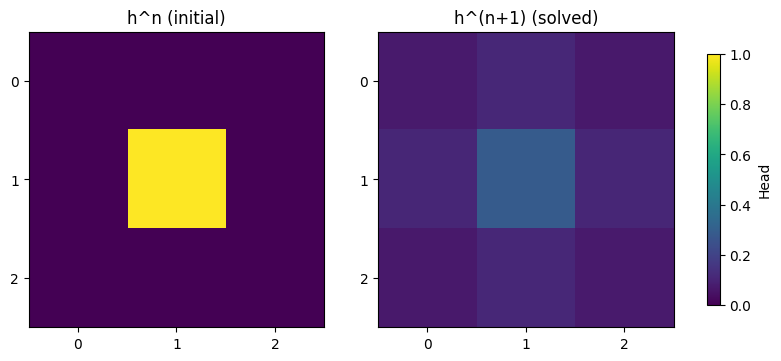

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), constrained_layout=True)

im0 = axes[0].imshow(h_n, cmap='viridis', vmin=0, vmax=max(h_n.max(), h_np1.max()))
axes[0].set_title('h^n (initial)')
axes[0].set_xticks(range(ncols))
axes[0].set_yticks(range(nrows))

im1 = axes[1].imshow(h_np1, cmap='viridis', vmin=0, vmax=max(h_n.max(), h_np1.max()))
axes[1].set_title('h^(n+1) (solved)')
axes[1].set_xticks(range(ncols))
axes[1].set_yticks(range(nrows))

cbar = fig.colorbar(im1, ax=axes, shrink=0.85)
cbar.set_label('Head')
plt.show()

## Expected Pattern

With a center mound initial condition and no external sources/sinks, one implicit step spreads head from the center to its neighbors.

For this parameter choice, the known analytical values are approximately:
- corners: 0.07142857
- edges: 0.10714286
- center: 0.28571429

## Optional: Head-Dependent T and C (Picard Iteration)

This section adds a minimal nonlinear test where transmissivity `T(h)` and capacity `C(h)` depend on the current head estimate.

At each timestep we iterate:
1. Evaluate `T` and `C` from current head guess
2. Rebuild `A` and `hs`
3. Solve for updated head
4. Check convergence

In [5]:
# Nonlinear coefficients as simple functions of head
def T_of_head(h):
    # Higher head -> slightly higher transmissivity (bounded positive)
    return np.clip(0.6 + 0.8 * np.maximum(h, 0.0), 0.2, None)

def C_of_head(h):
    # Capacity increases mildly with head
    return np.clip(0.8 + 0.4 * np.maximum(h, 0.0), 0.2, None)

def assemble_A_hs_nonlinear(h_guess, h_old, RR_flat, SINK_flat, theta=1.0, dx=1.0, dt=1.0):
    nrows, ncols = h_guess.shape
    N = nrows * ncols
    A = np.zeros((N, N), dtype=float)
    hs = np.zeros(N, dtype=float)

    T_cell = T_of_head(h_guess)
    C_cell = C_of_head(h_guess)

    def idx(i, j):
        return i * ncols + j

    for i in range(nrows):
        for j in range(ncols):
            p = idx(i, j)
            alpha = C_cell[i, j] * dx**2 / dt

            # Collect neighbors and interface transmissivities (simple arithmetic mean)
            nbrs = []
            if i > 0:
                nbrs.append((i - 1, j))
            if i < nrows - 1:
                nbrs.append((i + 1, j))
            if j > 0:
                nbrs.append((i, j - 1))
            if j < ncols - 1:
                nbrs.append((i, j + 1))

            Tsum = 0.0
            for (ni, nj) in nbrs:
                q = idx(ni, nj)
                Tij = 0.5 * (T_cell[i, j] + T_cell[ni, nj])
                A[p, q] = -theta * Tij
                Tsum += Tij

            A[p, p] = alpha + theta * Tsum

            # For theta=1, hs has old storage + known forcing
            hs[p] = alpha * h_old.ravel()[p] + (RR_flat[p] - SINK_flat[p]) * dx**2 / dt

    return A, hs

# Picard iteration for one nonlinear timestep
h_old = h_n.copy()
h_iter = h_old.copy()
max_iter = 30
tol = 1e-8

for it in range(1, max_iter + 1):
    A_nl, hs_nl = assemble_A_hs_nonlinear(
        h_guess=h_iter,
        h_old=h_old,
        RR_flat=RR_flat,
        SINK_flat=SINK_flat,
        theta=theta, dx=dx, dt=dt
    )
    h_new_flat = np.linalg.solve(A_nl, hs_nl)
    h_new = h_new_flat.reshape((nrows, ncols))

    err = np.max(np.abs(h_new - h_iter))
    h_iter = h_new
    if err < tol:
        print(f'Converged in {it} iterations, max change={err:.2e}')
        break
else:
    print(f'Not converged in {max_iter} iterations, last max change={err:.2e}')

print('\nNonlinear solved head h^(n+1):')
print(h_iter)

Converged in 8 iterations, max change=3.05e-09

Nonlinear solved head h^(n+1):
[[0.0740504  0.12258703 0.06694604]
 [0.11619526 0.32143181 0.11560232]
 [0.06838218 0.11927844 0.07280237]]
